Level 2 now works directly in logit space using the official get_component_cos_xpy / get_component_sin_xpy functions. Components are the cos(k(a+b)) and sin(k(a+b)) Fourier directions in the final logits: exactly what Section 4.4 and Figure 6 of the paper test.

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import einops
import matplotlib.pyplot as plt
import json
from pathlib import Path
from tqdm.notebook import tqdm
from transformer_lens import HookedTransformer, HookedTransformerConfig

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

RESULTS_DIR = Path("../results/level2")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
L1_RESULTS = Path("../results/level1/level1_results.json")
MODEL_PATH  = Path("../data/grokking_model.pt")

Using device: cpu


Dataset and Model

In [29]:
P = 113
EQ_TOKEN = P

all_a = torch.arange(P)
all_b = torch.arange(P)
aa, bb = torch.meshgrid(all_a, all_b, indexing='ij')
aa, bb = aa.flatten(), bb.flatten()
labels_all = (aa + bb) % P
inputs_all  = torch.stack([aa, bb, torch.full_like(aa, EQ_TOKEN)], dim=1)

N = len(inputs_all)
idx = torch.randperm(N, generator=torch.Generator().manual_seed(42))
n_test = int(0.3 * N)
train_inputs = inputs_all[idx[n_test:]]
test_inputs  = inputs_all[idx[:n_test]]
test_labels  = labels_all[idx[:n_test]]

cfg = HookedTransformerConfig(
    n_layers=1, n_heads=4, d_model=128, d_head=32,
    d_mlp=512, act_fn="relu", normalization_type=None,
    d_vocab=P + 1, d_vocab_out=P, n_ctx=3,
    use_attn_result=True,
)
model = HookedTransformer(cfg)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device).eval()

with torch.no_grad():
    te_acc = (model(test_inputs.to(device))[:, -1, :].argmax(-1) == test_labels.to(device)).float().mean()
print(f"Test accuracy: {te_acc:.4f}  ✓")

Moving model to device:  cpu
Test accuracy: 1.0000  ✓


Build Fourier basis and key frequency helpers (official code)

In [30]:
# Orthonormal Fourier basis — identical to official notebook
fourier_basis= [torch.ones(P) / np.sqrt(P)]
fourier_basis_names = ['Const']

for i in range(1, P // 2 + 1):
    cos_v = torch.cos(2 * torch.pi * torch.arange(P) * i / P)
    sin_v = torch.sin(2 * torch.pi * torch.arange(P) * i / P)
    fourier_basis.append(cos_v / cos_v.norm())
    fourier_basis.append(sin_v / sin_v.norm())
    fourier_basis_names.append(f'cos {i}')
    fourier_basis_names.append(f'sin {i}')

fourier_basis = torch.stack(fourier_basis, dim=0).to(device)   # [113, 113]

def fourier_2d_basis_term(x_index, y_index):
    """Outer product of two 1D Fourier basis vectors, flattened to [p^2]."""
    return (fourier_basis[x_index][:, None] * fourier_basis[y_index][None, :]).flatten()

def get_component_cos_xpy(logits, freq):
    """
    Projects logits onto the cos(freq*(a+b)) direction in 2D Fourier space.
    logits shape: [p*p, p]
    Returns same shape: the projection component only.
    (Direct translation from official notebook)
    """
    cosx_cosy = fourier_2d_basis_term(2 * freq - 1, 2 * freq - 1)
    sinx_siny = fourier_2d_basis_term(2 * freq, 2 * freq)
    cos_xpy = (cosx_cosy - sinx_siny) / np.sqrt(2)   # [p^2]
    return cos_xpy[:, None] * (cos_xpy[None, :] @ logits)   # [p^2, p]

def get_component_sin_xpy(logits, freq):
    """Projects logits onto the sin(freq*(a+b)) direction."""
    sinx_cosy = fourier_2d_basis_term(2 * freq,     2 * freq - 1)
    cosx_siny = fourier_2d_basis_term(2 * freq - 1, 2 * freq)
    sin_xpy = (sinx_cosy + cosx_siny) / np.sqrt(2)   # [p^2]
    return sin_xpy[:, None] * (sin_xpy[None, :] @ logits)   # [p^2, p]

print("Fourier basis and helper functions ready.")

Fourier basis and helper functions ready.


Load key frequencies from Level 1 results

In [31]:
with open(L1_RESULTS) as f:
    l1 = json.load(f)
KEY_FREQS = l1["key_freqs"]
print(f"Key frequencies (from Level 1): {KEY_FREQS}")

Key frequencies (from Level 1): [14, 49, 17]


Define components: one cos + one sin per key frequency

In [32]:
# Each component is a (frequency, cos/sin) Fourier direction in logit space
# This directly matches the official paper's ablation 
COMPONENTS = []
for k in KEY_FREQS:
    COMPONENTS.append({"name": f"cos_{k}", "k": k, "part": "cos"})
    COMPONENTS.append({"name": f"sin_{k}", "k": k, "part": "sin"})

print(f"Level 2 components: {len(COMPONENTS)}")
for c in COMPONENTS:
    print(f"  {c['name']}")
print(f"\nTotal component space: {len(COMPONENTS)}  "
      f"(2 directions per key frequency)")

Level 2 components: 6
  cos_14
  sin_14
  cos_49
  sin_49
  cos_17
  sin_17

Total component space: 6  (2 directions per key frequency)


Run model on ALL inputs (p*p) to get full logit tensor

In [33]:
# We need all p*p logits to work in the 2D Fourier basis
# (following official notebook)
all_inputs_dev = inputs_all.to(device)    # [p*p, 3]
all_labels_dev = labels_all.to(device)    # [p*p]

with torch.no_grad():
    all_logits = model(all_inputs_dev)[:, -1, :]   # [p*p, p]

print(f"Full logit tensor shape: {all_logits.shape}")
print(f"Original loss (all data): " f"{torch.nn.CrossEntropyLoss()(all_logits, all_labels_dev):.6f}")

Full logit tensor shape: torch.Size([12769, 113])
Original loss (all data): 0.000348


Faithfulness metric: logit of correct token 

In [34]:
def logit_of_correct_all(logits, labels):
    """Logit assigned to the correct answer for each input; shape [p*p]."""
    return logits[torch.arange(len(labels)), labels]

def recovery_score(patched_metric, corrupted_metric, clean_metric):
    """RS = (patched - corrupted).mean / (clean - corrupted).mean
    Consistent with Level 1 and Level 3 grokking notebooks."""
    gap = (clean_metric - corrupted_metric).mean().item()
    if abs(gap) < 1e-8:
        return 0.0
    return (patched_metric.mean().item() - corrupted_metric.mean().item()) / gap

# Clean baseline
clean_metric = logit_of_correct_all(all_logits, all_labels_dev)
clean_acc    = (all_logits.argmax(-1) == all_labels_dev).float().mean().item()

# Corrupted baseline: zero out ALL key-frequency components from the logits
corrupted_logits = all_logits.clone()
for k in KEY_FREQS:
    corrupted_logits = corrupted_logits \
        - get_component_cos_xpy(corrupted_logits, k) \
        - get_component_sin_xpy(corrupted_logits, k)

corrupted_metric = logit_of_correct_all(corrupted_logits, all_labels_dev)
corrupted_acc    = (corrupted_logits.argmax(-1) == all_labels_dev).float().mean().item()

print(f"Clean     logit(correct): {clean_metric.mean():.4f}  acc={clean_acc:.4f}")
print(f"Corrupted logit(correct): {corrupted_metric.mean():.4f}  acc={corrupted_acc:.4f}")
print(f"Gap to recover: {(clean_metric - corrupted_metric).mean():.4f}")

Clean     logit(correct): 38.9340  acc=1.0000
Corrupted logit(correct): -6.1759  acc=0.0121
Gap to recover: 45.1099


Per-component patching loop

For each component, remove all key frequency components from the logits, then restore just this one. This is the direct logit-space analogue of activation patching.

In [35]:
scores = {}

for comp in tqdm(COMPONENTS, desc="Patching frequency components"):
    cname = comp["name"]
    k     = comp["k"]
    part  = comp["part"]

    # Start from fully corrupted logits (all key freqs removed)
    patched = all_logits.clone()
    for kk in KEY_FREQS:
        patched = patched \
            - get_component_cos_xpy(patched, kk) \
            - get_component_sin_xpy(patched, kk)

    # Restore just this one component from the clean logits
    if part == "cos":
        patched = patched + get_component_cos_xpy(all_logits, k)
    else:
        patched = patched + get_component_sin_xpy(all_logits, k)

    patched_metric = logit_of_correct_all(patched, all_labels_dev)
    scores[cname]  = recovery_score(patched_metric, corrupted_metric, clean_metric)
    print(f"  {cname:10s}  logit(correct)={patched_metric.mean():.4f}  RS={scores[cname]:.4f}")

Patching frequency components:   0%|          | 0/6 [00:00<?, ?it/s]

  cos_14      logit(correct)=4.9250  RS=0.2461
  sin_14      logit(correct)=8.1897  RS=0.3185
  cos_49      logit(correct)=-3.0257  RS=0.0698
  sin_49      logit(correct)=-2.7427  RS=0.0761
  cos_17      logit(correct)=0.9751  RS=0.1585
  sin_17      logit(correct)=-0.2670  RS=0.1310


Criterion 1 and Criterion2

  Level 2 — Logit-space Fourier components
  Key frequencies : [14, 49, 17]
  Threshold τ     : 0.1
  Criterion 1  Faithfulness RS    : 0.8541
  Criterion 2  Description length : 0.6667  (4 / 6 components)
  Circuit components: ['cos_14', 'sin_14', 'cos_17', 'sin_17']


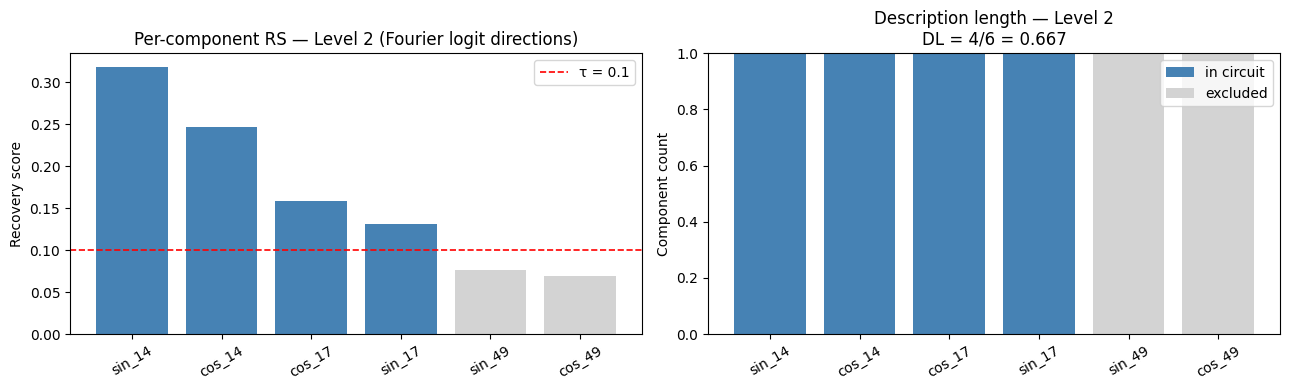

In [ ]:
THRESHOLD = 0.10  # same τ as Level 1 
# Circuit selection 
circuit_components = [name for name, rs in scores.items() if rs >= THRESHOLD]

# Criterion 1: restore all circuit components together
circuit_logits = all_logits.clone()
for kk in KEY_FREQS:
    circuit_logits = circuit_logits \
        - get_component_cos_xpy(circuit_logits, kk) \
        - get_component_sin_xpy(circuit_logits, kk)

for cname in circuit_components:
    comp = next(c for c in COMPONENTS if c["name"] == cname)
    if comp["part"] == "cos":
        circuit_logits = circuit_logits + get_component_cos_xpy(all_logits, comp["k"])
    else:
        circuit_logits = circuit_logits + get_component_sin_xpy(all_logits, comp["k"])

circuit_metric = logit_of_correct_all(circuit_logits, all_labels_dev)
faithfulness   = recovery_score(circuit_metric, corrupted_metric, clean_metric)

# Criterion 2 description length as component fraction
# How many of the len(COMPONENTS) Fourier directions must be named?
# Lower = more compressed = better from a description-length perspective.
n_circuit_components = len(circuit_components)
description_length   = n_circuit_components / len(COMPONENTS)   # in [0, 1]

# Summary 
sorted_comps  = sorted(scores.items(), key=lambda x: x[1], reverse=True)
names_sorted  = [x[0] for x in sorted_comps]
scores_sorted = torch.tensor([x[1] for x in sorted_comps])
in_circuit    = [n in circuit_components for n in names_sorted]

print("=" * 57)
print("  Level 2 — Logit-space Fourier components")
print("=" * 57)
print(f"  Key frequencies : {KEY_FREQS}")
print(f"  Threshold τ     : {THRESHOLD}")
print(f"  Criterion 1  Faithfulness RS    : {faithfulness:.4f}")
print(f"  Criterion 2  Description length : {description_length:.4f}  "
      f"({n_circuit_components} / {len(COMPONENTS)} components)")
print(f"  Circuit components: {circuit_components}")
print("=" * 57)

# Plots 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

colors = ["steelblue" if ic else "lightgray" for ic in in_circuit]
ax1.bar(names_sorted, scores_sorted.numpy(), color=colors)
ax1.axhline(THRESHOLD, color="red", linestyle="--", linewidth=1.2,
            label=f"τ = {THRESHOLD}")
ax1.axhline(0, color="black", linewidth=0.5)
ax1.set_ylabel("Recovery score")
ax1.set_title("Per-component RS — Level 2 (Fourier logit directions)")
ax1.tick_params(axis="x", rotation=30)
ax1.legend()

# Bar: in-circuit vs excluded component count
x = range(len(names_sorted))
in_vals  = [1 if ic else 0 for ic in in_circuit]
out_vals = [1 - v for v in in_vals]
ax2.bar(x, in_vals,  color="steelblue", label="in circuit")
ax2.bar(x, out_vals, bottom=in_vals, color="lightgray", label="excluded")
ax2.set_xticks(list(x))
ax2.set_xticklabels(names_sorted, rotation=30)
ax2.set_ylabel("Component count")
ax2.set_title(f"Description length — Level 2\n"
              f"DL = {n_circuit_components}/{len(COMPONENTS)} = {description_length:.3f}")
ax2.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "level2_recovery_scores.png", dpi=150)
plt.show()

Save Results

In [37]:
results = {
    "level": 2,
    "task": "modular_arithmetic_mod113",
    "method": "logit_fourier_components",
    "metric": "logit_of_correct_token",
    "key_freqs": KEY_FREQS,
    "n_components": len(COMPONENTS),
    "components": [c["name"] for c in COMPONENTS],
    "clean_metric_mean":      clean_metric.mean().item(),
    "corrupted_metric_mean":  corrupted_metric.mean().item(),
    "threshold_tau": THRESHOLD,
    "criterion1_faithfulness": faithfulness,
    "criterion2_description_length": description_length,
    "criterion2_circuit_components": n_circuit_components,
    "criterion2_total_components": len(COMPONENTS),
    "circuit_components": circuit_components,
    "all_recovery_scores": scores,
}

with open(RESULTS_DIR / "level2_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"Saved to {RESULTS_DIR}/level2_results.json")

Saved to ..\results\level2/level2_results.json
